In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [2]:
# 현재 작업 디렉토리(notebooks)의 부모 디렉토리(root)를 경로에 추가
# 한 번만 실행
os.chdir(os.path.abspath('..'))
print(os.getcwd())

df = pd.read_csv('data/df_cleaned.csv')
df.head()

c:\workspace\camp\project\airbnb_price_prediction


,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,log_price,log_estimated_revenue_l365d,amenities_list,has_self_checkin,has_wifi,has_kitchen,has_dryer,has_air_conditioning,has_heating,has_dedicated_workspace,has_hair_dryer,has_iron,has_gym,has_bbq_grill,has_breakfast,has_fireplace,has_smoking_allowed,has_pets_allowed,has_wine_glasses,has_crib,has_city_skyline_view,has_river_view,has_luggage_dropoff_allowed,has_long_term_stays_allowed,has_private_entrance,has_exterior_security_cameras,has_elevator,has_lock_on_bedroom_door,has_tub,has_washer,has_pool,has_alarm,has_garden_courtyard_view,has_outdoor,has_free_parking,amenities_count,count_appliances_expensive,has_ott
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,False,Prospect Heights,1.0,3.0,True,True,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200.0,90,365,90.0,90.0,365.0,365.0,90.0,365.0,True,27,57,87,362,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,False,1,0,1,0,0.05,1,1,1,5.303305,0.000000,"['refrigerator', 'dishes and silverware', 'wif...",0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,7,1,0
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,1.00,False,East Harlem,1.0,1.0,True,True,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82.0,30,999,30.0,30.0,999.0,999.0,30.0,999.0,True,0,0,0,204,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,False,1,0,1,0,0.58,1,1,0,4.418841,0.000000,"['oven', 'blender', 'luggage dropoff allowed',...",0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,32,5,0
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,1.0,0.40,False,Boerum Hill,1.0,3.0,True,True,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765.0,3,60,3.0,3.0,60.

In [3]:
df.info(verbose = True, show_counts = True)

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 109 columns):
 #    Column                                        Non-Null Count  Dtype  
---   ------                                        --------------  -----  
 0    id                                            22308 non-null  int64  
 1    name                                          22308 non-null  str    
 2    description                                   21903 non-null  str    
 3    neighborhood_overview                         12262 non-null  str    
 4    host_id                                       22308 non-null  int64  
 5    host_name                                     22288 non-null  str    
 6    host_since                                    22288 non-null  str    
 7    host_location                                 17025 non-null  str    
 8    host_about                                    13391 non-null  str    
 9    host_response_time                            17915 non-nul

## describe 보고 생각해본 것

In [4]:
df.describe(include = 'all').T[60:70]

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
review_scores_value,22308.0,NaN,NaN,NaN,3.2076,2.16485,0.0,0.0,4.56,4.82,5.0
license,4463,1894,Exempt,2064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
instant_bookable,22308,2,False,16618,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calculated_host_listings_count,22308.0,NaN,NaN,NaN,89.47279,263.516627,1.0,1.0,3.0,19.0,1194.0
calculated_host_listings_count_entire_homes,22308.0,NaN,NaN,NaN,74.823247,259.293166,0.0,0.0,1.0,6.0,1194.0
calculated_host_listings_count_private_rooms,22308.0,NaN,NaN,NaN,12.25009,59.627479,0.0,0.0,0.0,2.0,616.0
calculated_host_listings_count_shared_rooms,22308.0,NaN,NaN,NaN,0.017931,0.196899,0.0,0.0,0.0,0.0,4.0
reviews_per_month,22308.0,NaN,NaN,NaN,0.806486,1.929625,0.0,0.0,0.21,0.94,117.98
host_verifications_email,22308.0,NaN,NaN,NaN,0.900484,0.29936,0.0,1.0,1.0,1.0,1.0
host_verifications_phone,22308.0,NaN,NaN,NaN,0.998745,0.035407,0.0,1.0,1.0,1.0,1.0


### 0. 현재 운영을 안 하고 있는 숙소

In [5]:
base_date = pd.to_datetime('2025-03-02')
host_since = pd.to_datetime(df['host_since'])
df['host_experience_months'] = (base_date.year - host_since.dt.year) * 12 + (base_date.month - host_since.dt.month)

In [6]:
# 리뷰가 없는 숙소이면서 신규 호스트가 아닌 경우
print(len(df[(df['number_of_reviews'] == 0) & (df['host_experience_months'] > 12)]))
cond1 = (df['number_of_reviews'] == 0) & (df['host_experience_months'] > 12)

6178


In [7]:
# 과거의 1년 추정 점유율이 0이고, 현재 숙박 예약도 하지 않은 곳 -> 유령 숙소
cond2 = (df['availability_30'] == 30) & (df['availability_60'] == 60) & (df['availability_90'] == 90) & (df['availability_365'] == 365) & (df['estimated_occupancy_l365d'] == 0)
len(df[cond1 | cond2])

7504

In [8]:
df = df.loc[~(cond1 | cond2)]
len(df)

14804

### 1. 호스트 정보

In [9]:
# 숙소 이름이 같은 경우, 동일한 price가 많음
# 위/경도, 숙소 이름, 가격이 같은 경우에는 어떻게 합칠지를 생각해봐야 함
n = 0
count = 0

duplicated_name = df[df['name'].duplicated()]['name'].unique()

duplicated_cnt = df[df['name'].isin(duplicated_name)].groupby(['name'])['price'].agg(
    ['count']
)

# 중복값 count 확인
display(duplicated_cnt['count'].describe())

# # 예시
display(df[df['name'] == duplicated_name[0]]['price'])

count    172.000000
mean       2.610465
std        1.440641
min        2.000000
25%        2.000000
50%        2.000000
75%        3.000000
max       13.000000
Name: count, dtype: float64

146    246.0
161    246.0
162    246.0
163    246.0
164    246.0
174    246.0
175    246.0
176    246.0
197    246.0
198    246.0
199    246.0
200    246.0
204    246.0
Name: price, dtype: float64

In [10]:
# 호스트 정보를 볼 때, duplicated 써서 중복 제거 후 보기
df_drop_dup_host = df.drop_duplicates(subset = ['longitude','latitude','name','log_price'])
df_drop_dup_host.head()

,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,log_price,log_estimated_revenue_l365d,amenities_list,has_self_checkin,has_wifi,has_kitchen,has_dryer,has_air_conditioning,has_heating,has_dedicated_workspace,has_hair_dryer,has_iron,has_gym,has_bbq_grill,has_breakfast,has_fireplace,has_smoking_allowed,has_pets_allowed,has_wine_glasses,has_crib,has_city_skyline_view,has_river_view,has_luggage_dropoff_allowed,has_long_term_stays_allowed,has_private_entrance,has_exterior_security_cameras,has_elevator,has_lock_on_bedroom_door,has_tub,has_washer,has_pool,has_alarm,has_garden_courtyard_view,has_outdoor,has_free_parking,amenities_count,count_appliances_expensive,has_ott,host_experience_months
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,False,Prospect Heights,1.0,3.0,True,True,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200.0,90,365,90.0,90.0,365.0,365.0,90.0,365.0,True,27,57,87,362,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,False,1,0,1,0,0.05,1,1,1,5.303305,0.000000,"['refrigerator', 'dishes and silverware', 'wif...",0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,7,1,0,183.0
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,1.00,False,East Harlem,1.0,1.0,True,True,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82.0,30,999,30.0,30.0,999.0,999.0,30.0,999.0,True,0,0,0,204,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,False,1,0,1,0,0.58,1,1,0,4.418841,0.000000,"['oven', 'blender', 'luggage dropoff allowed',...",0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,32,5,0,176.0
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,1.0,0.40,False,Boerum Hill,1.0,3.0,True,True,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"

<Axes: xlabel='host_experience_months', ylabel='Count'>

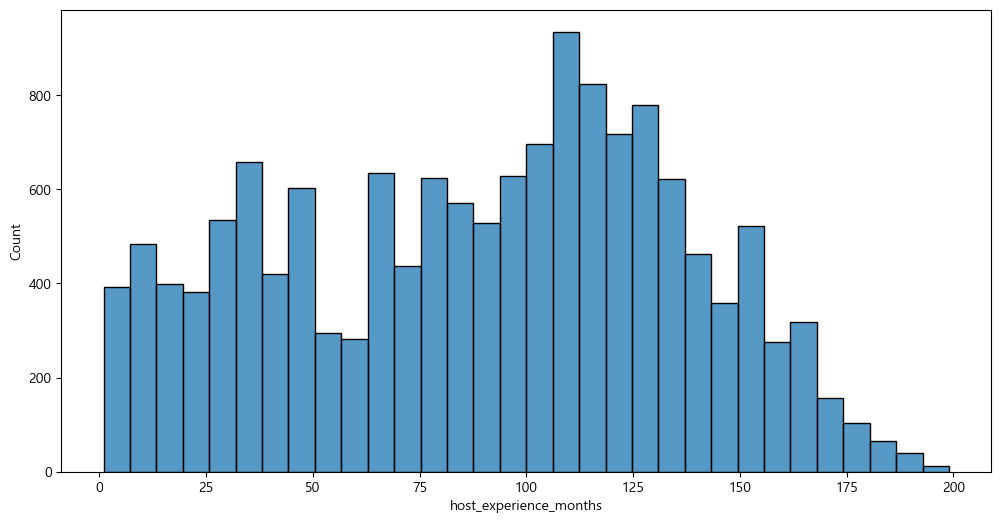

In [11]:
# 호스트 연차 기준
sns.histplot(df_drop_dup_host['host_experience_months'])

<Axes: xlabel='host_experience_months', ylabel='log_price'>

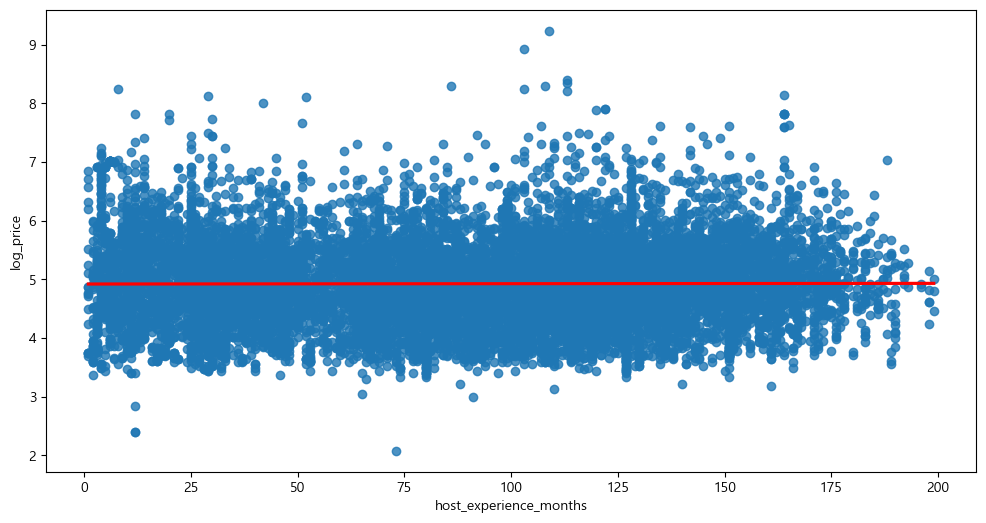

In [12]:
sns.regplot(data = df_drop_dup_host, x = 'host_experience_months', y = 'log_price', 
            line_kws = {'color':'red'})

In [13]:
def convert_host_location(df):
    location_list = []

    parts = df['host_location'].str.split(', ')

    for i, loc in enumerate(parts):
        # 결측치 처리
        if not isinstance(loc, list):
            value = np.nan
        else:
            last_loc = loc[-1].strip()
        
            # 뉴욕
            if last_loc == 'NY' or 'New York' in loc:
                value = 1
            # 그 외 미국 내부
            elif len(last_loc) == 2:
                value = 2
            # 'United States'
            elif last_loc == 'United States':
                if 'New York' in loc[0]:
                    value = 1
                else:
                    value = 2
            else:
                value = 3
                
        location_list.append(value)
    return location_list

host_loc = convert_host_location(df)
df['host_location'] = host_loc

df_drop_dup_host = df.drop_duplicates(subset = ['longitude','latitude','name','log_price'])

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, levene, probplot
import pingouin as pg

def perform_anova(df, group_col, target='log_price'):

    groups = df[group_col].dropna().unique()
    groups = sorted(groups)
    groups_data = [df.loc[df[group_col] == g, target] for g in groups]

    print(f"=== [{group_col}] 기준 [{target}] 분석 시작 ===")
    print(f"분석 그룹: {groups}")

    print('\n=== 히스토그램 시각화 ===')
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(data=df, x=target, hue=group_col, stat='probability', common_norm=False, ax=ax)
    plt.title(f'Histogram of {target} by {group_col}')
    plt.show()
    
    print('\n=== QQ Plot 시각화 ===')
    fig, axs = plt.subplots(1, len(groups), figsize=(5 * len(groups), 4))
    if len(groups) == 1: axs = [axs] 
    
    for i, g in enumerate(groups):
        data = df.loc[df[group_col] == g, target]
        probplot(data, dist="norm", plot=axs[i])
        axs[i].set_title(f'Group {g} QQ Plot')
    
    plt.tight_layout()
    plt.show()
    
    print('\n=== 정규성 검정 ===')
    for g in groups:
        data = df.loc[df[group_col] == g, target]
        stat, p_val = shapiro(data)
        print(f'{g} 데이터 개수 : {len(data)} ,', end=' ')
        print(f'{g} 정규성 검정 결과 p-value : {p_val:.4f}')

    print('\n=== 등분산성 검정 ===')
    lev_stat, l_pval = levene(*groups_data)
    result_msg = '등분산성 만족' if l_pval >= 0.05 else '등분산성 불만족'
    print(f'{result_msg}\n')

    print(f"=== ANOVA / Welch's ANOVA 수행 ===")
    if l_pval >= 0.05:
        res = pg.anova(data=df, dv=target, between=group_col, detailed=True)
        p_val_result = res['p_unc'].values[0]
        eta_sq = res['np2'].values[0]
    else:
        res = pg.welch_anova(data=df, dv=target, between=group_col)
        p_val_result = res['p_unc'].values[0]
        eta_sq = res['np2'].values[0]

    print(f'ANOVA results p-value : {p_val_result:.4f}')
    
    print(f'\n=== 효과 크기 ===')
    aov = pg.anova(data=df, dv=target, between=group_col, detailed=True)
    ss_between = aov.loc[0, 'SS']
    df_between = aov.loc[0, 'DF']
    ss_total = aov['SS'].sum()
    ms_within = aov.loc[1, 'MS']
    omega_sq = (ss_between - (df_between * ms_within)) / (ss_total + ms_within)

    print(f'에타 제곱 : {eta_sq:.4f}, 오메가 제곱 : {omega_sq:.4f}')

    print("\n=== 사후 검정 (Games-Howell) ===")
    posthoc = pg.pairwise_gameshowell(data=df, dv=target, between=group_col)
    
    print(f"=== 분석 완료 ===\n")
    return posthoc

=== [host_location] 기준 [log_price] 분석 시작 ===
분석 그룹: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]

=== 히스토그램 시각화 ===


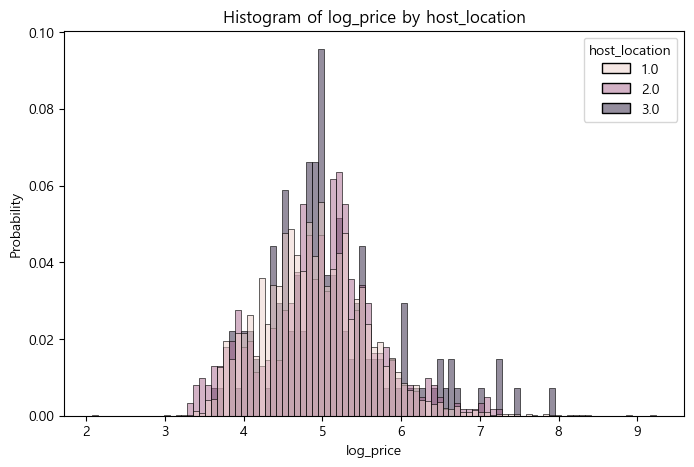


=== QQ Plot 시각화 ===


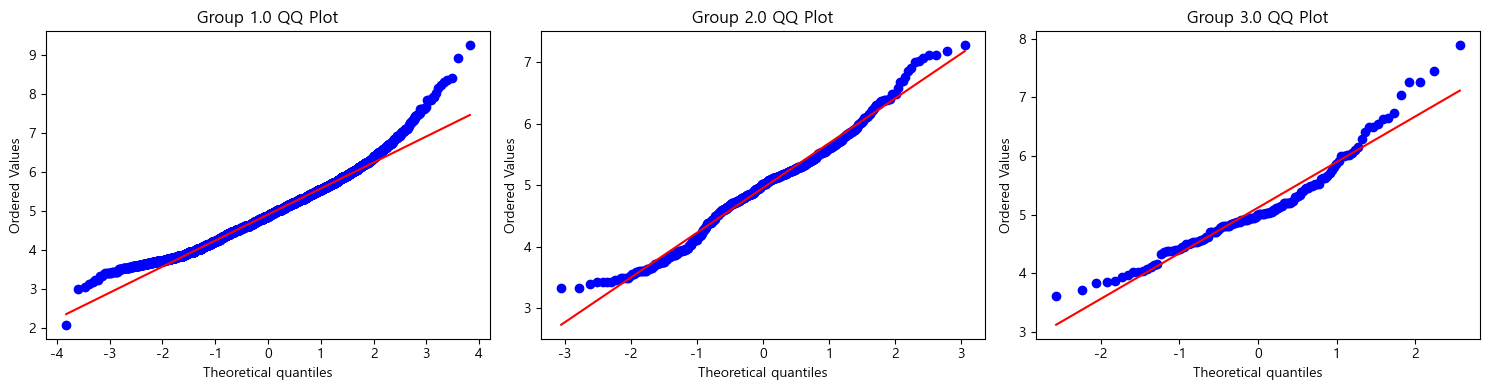


=== 정규성 검정 ===
1.0 데이터 개수 : 10553 , 1.0 정규성 검정 결과 p-value : 0.0000
2.0 데이터 개수 : 615 , 2.0 정규성 검정 결과 p-value : 0.0000
3.0 데이터 개수 : 136 , 3.0 정규성 검정 결과 p-value : 0.0000

=== 등분산성 검정 ===
등분산성 만족

=== ANOVA / Welch's ANOVA 수행 ===
ANOVA results p-value : 0.0002

=== 효과 크기 ===
에타 제곱 : 0.0015, 오메가 제곱 : 0.0013

=== 사후 검정 (Games-Howell) ===
=== 분석 완료 ===



,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,1.0,2.0,4.902446,4.958661,-0.056215,0.030197,-1.861636,675.894386,0.150757,-0.083209
1,1.0,3.0,4.902446,5.116567,-0.214121,0.068073,-3.145440,137.529392,0.005732,-0.317763
2,2.0,3.0,4.958661,5.116567,-0.157906,0.073893,-2.136949,189.449887,0.085193,-0.212580


In [15]:
perform_anova(df_drop_dup_host, 'host_location', 'log_price')

In [16]:
# 설명 1, 아니면 0
df['host_about'][:5]

0    I’m an urban planner working for an internatio...
1                                                  NaN
2    I am a lawyer and work as an executive at an a...
3    I have been a New Yorker for a long time\n and...
4    I am a music producer. And my wife is a hair s...
Name: host_about, dtype: str

In [17]:
df['host_about'].isna().sum() / len(df)

np.float64(0.41373952985679546)

In [ ]:
df['description'] = df['description'].map(lambda x: 0 if pd.isna(x) else 1)
df['host_about'] = df['host_about'].map(lambda x: 0 if pd.isna(x) else 1)

=== [host_response_time] 기준 [log_price] 분석 시작 ===
분석 그룹: ['a few days or more', 'within a day', 'within a few hours', 'within an hour']

=== 히스토그램 시각화 ===


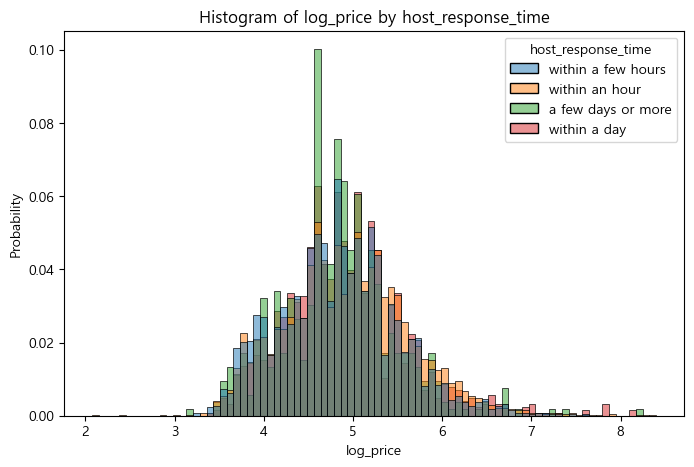


=== QQ Plot 시각화 ===


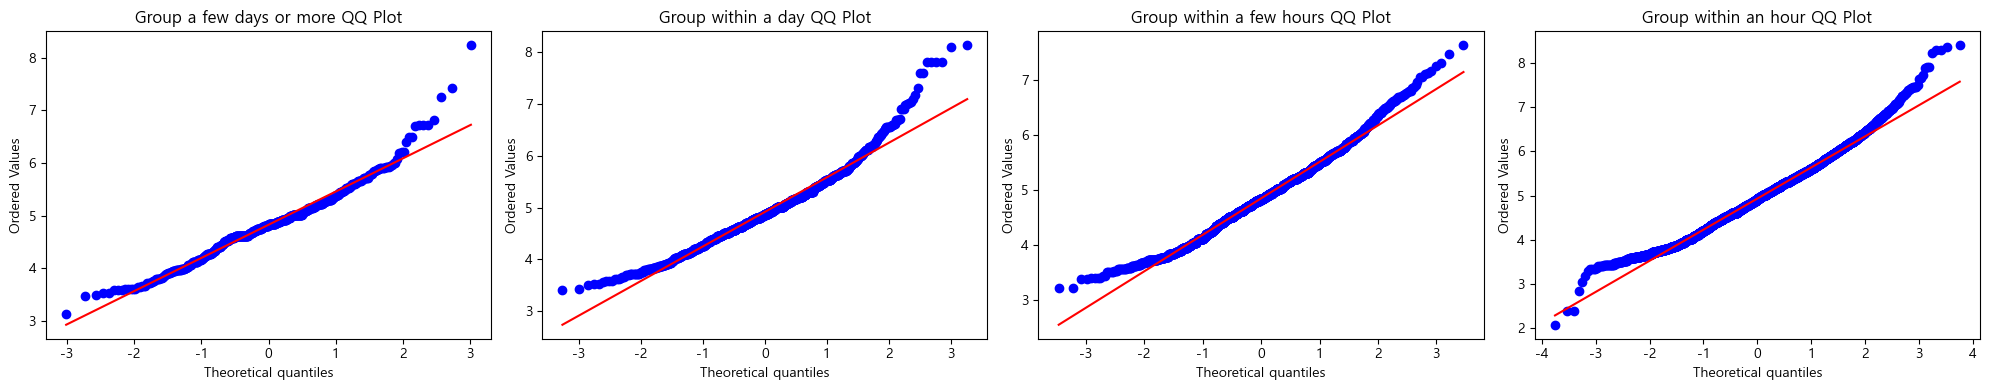


=== 정규성 검정 ===
a few days or more 데이터 개수 : 529 , a few days or more 정규성 검정 결과 p-value : 0.0000
within a day 데이터 개수 : 1257 , within a day 정규성 검정 결과 p-value : 0.0000
within a few hours 데이터 개수 : 2592 , within a few hours 정규성 검정 결과 p-value : 0.0000
within an hour 데이터 개수 : 8009 , within an hour 정규성 검정 결과 p-value : 0.0000

=== 등분산성 검정 ===
등분산성 불만족

=== ANOVA / Welch's ANOVA 수행 ===
ANOVA results p-value : 0.0000

=== 효과 크기 ===
에타 제곱 : 0.0041, 오메가 제곱 : 0.0032

=== 사후 검정 (Games-Howell) ===
=== 분석 완료 ===



,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,a few days or more,within a day,4.825145,4.915445,-0.090300,0.033803,-2.671404,1050.426050,3.836603e-02,-0.134951
1,a few days or more,within a few hours,4.825145,4.840527,-0.015382,0.030745,-0.500308,779.601446,9.589859e-01,-0.023238
2,a few days or more,within an hour,4.825145,4.932802,-0.107657,0.028922,-3.722378,616.319667,1.230422e-03,-0.153113
3,within a day,within a few hours,4.915445,4.840527,0.074919,0.023233,3.224697,2438.660053,6.995295e-03,0.111647
4,within a day,within an hour,4.915445,4.932802,-0.017357,0.020760,-0.836051,1709.716746,8.372980e-01,-0.024670
5,within a few hours,within an hour,4.840527,4.932802,-0.092275,0.015284,-6.037341,4625.821918,1.013170e-08,-0.132333


In [19]:
perform_anova(df_drop_dup_host, 'host_response_time', 'log_price')

<Axes: xlabel='host_response_rate', ylabel='log_price'>

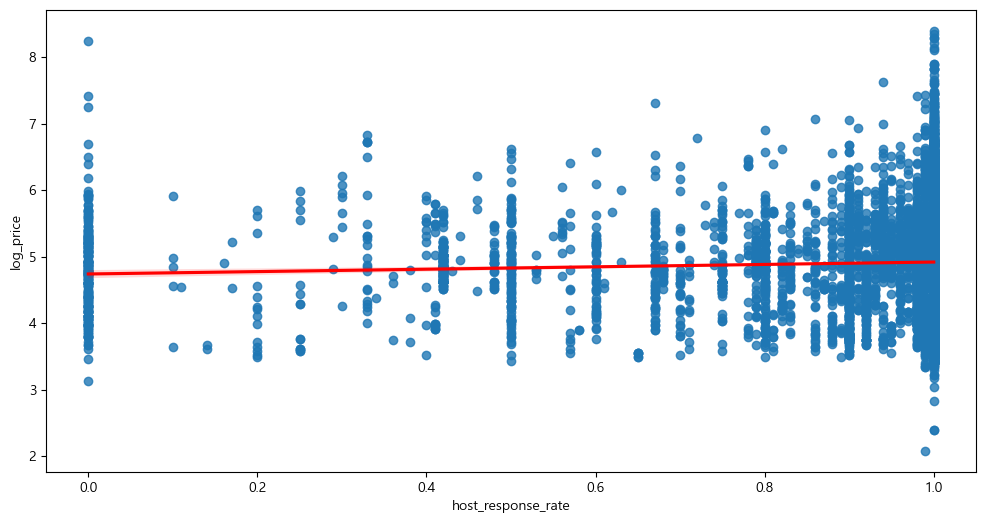

In [20]:
sns.regplot(data = df_drop_dup_host, x = 'host_response_rate', y = 'log_price', 
            line_kws = {'color':'red'})

<Axes: xlabel='host_acceptance_rate', ylabel='log_price'>

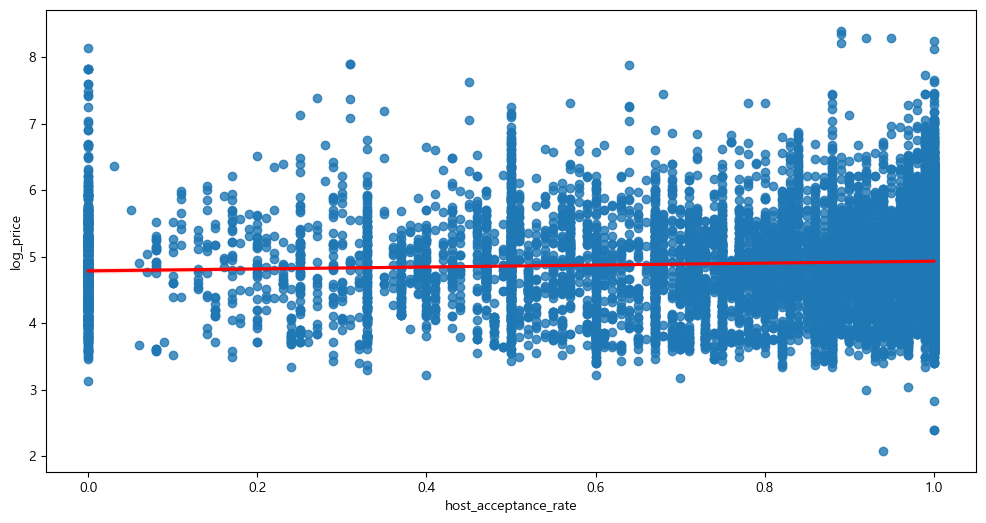

In [21]:
sns.regplot(data = df_drop_dup_host, x = 'host_acceptance_rate', y = 'log_price', 
            line_kws = {'color':'red'})

Label Encoding

One Hot Encoding

파생변수로 생성해야 할 변수
[host_since -> 운영 연차 / ]

결측치를 처리해야 할 변수

극단값 및 이상치 처리 변수들

주의 사항 및 분석 한계점에 적어둘 내용

<Axes: >

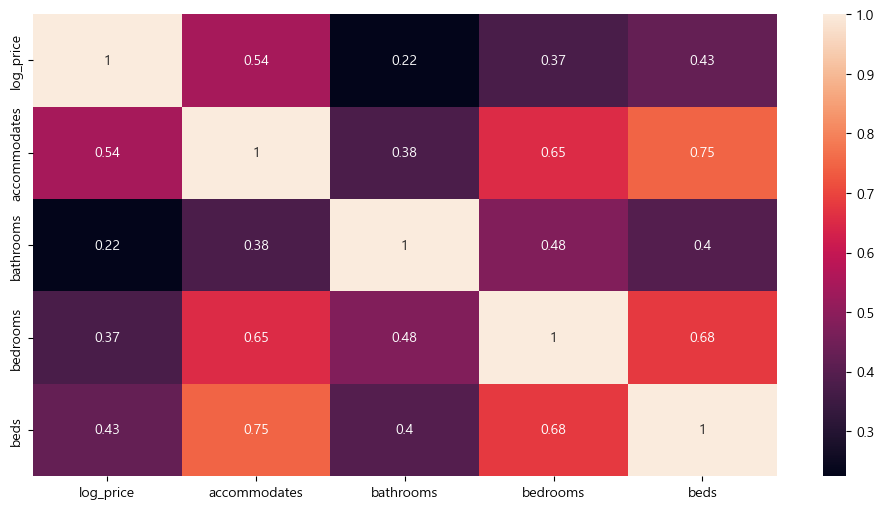

In [22]:
sns.heatmap(df[['log_price','accommodates','bathrooms','bedrooms','beds']].corr(), annot = True)

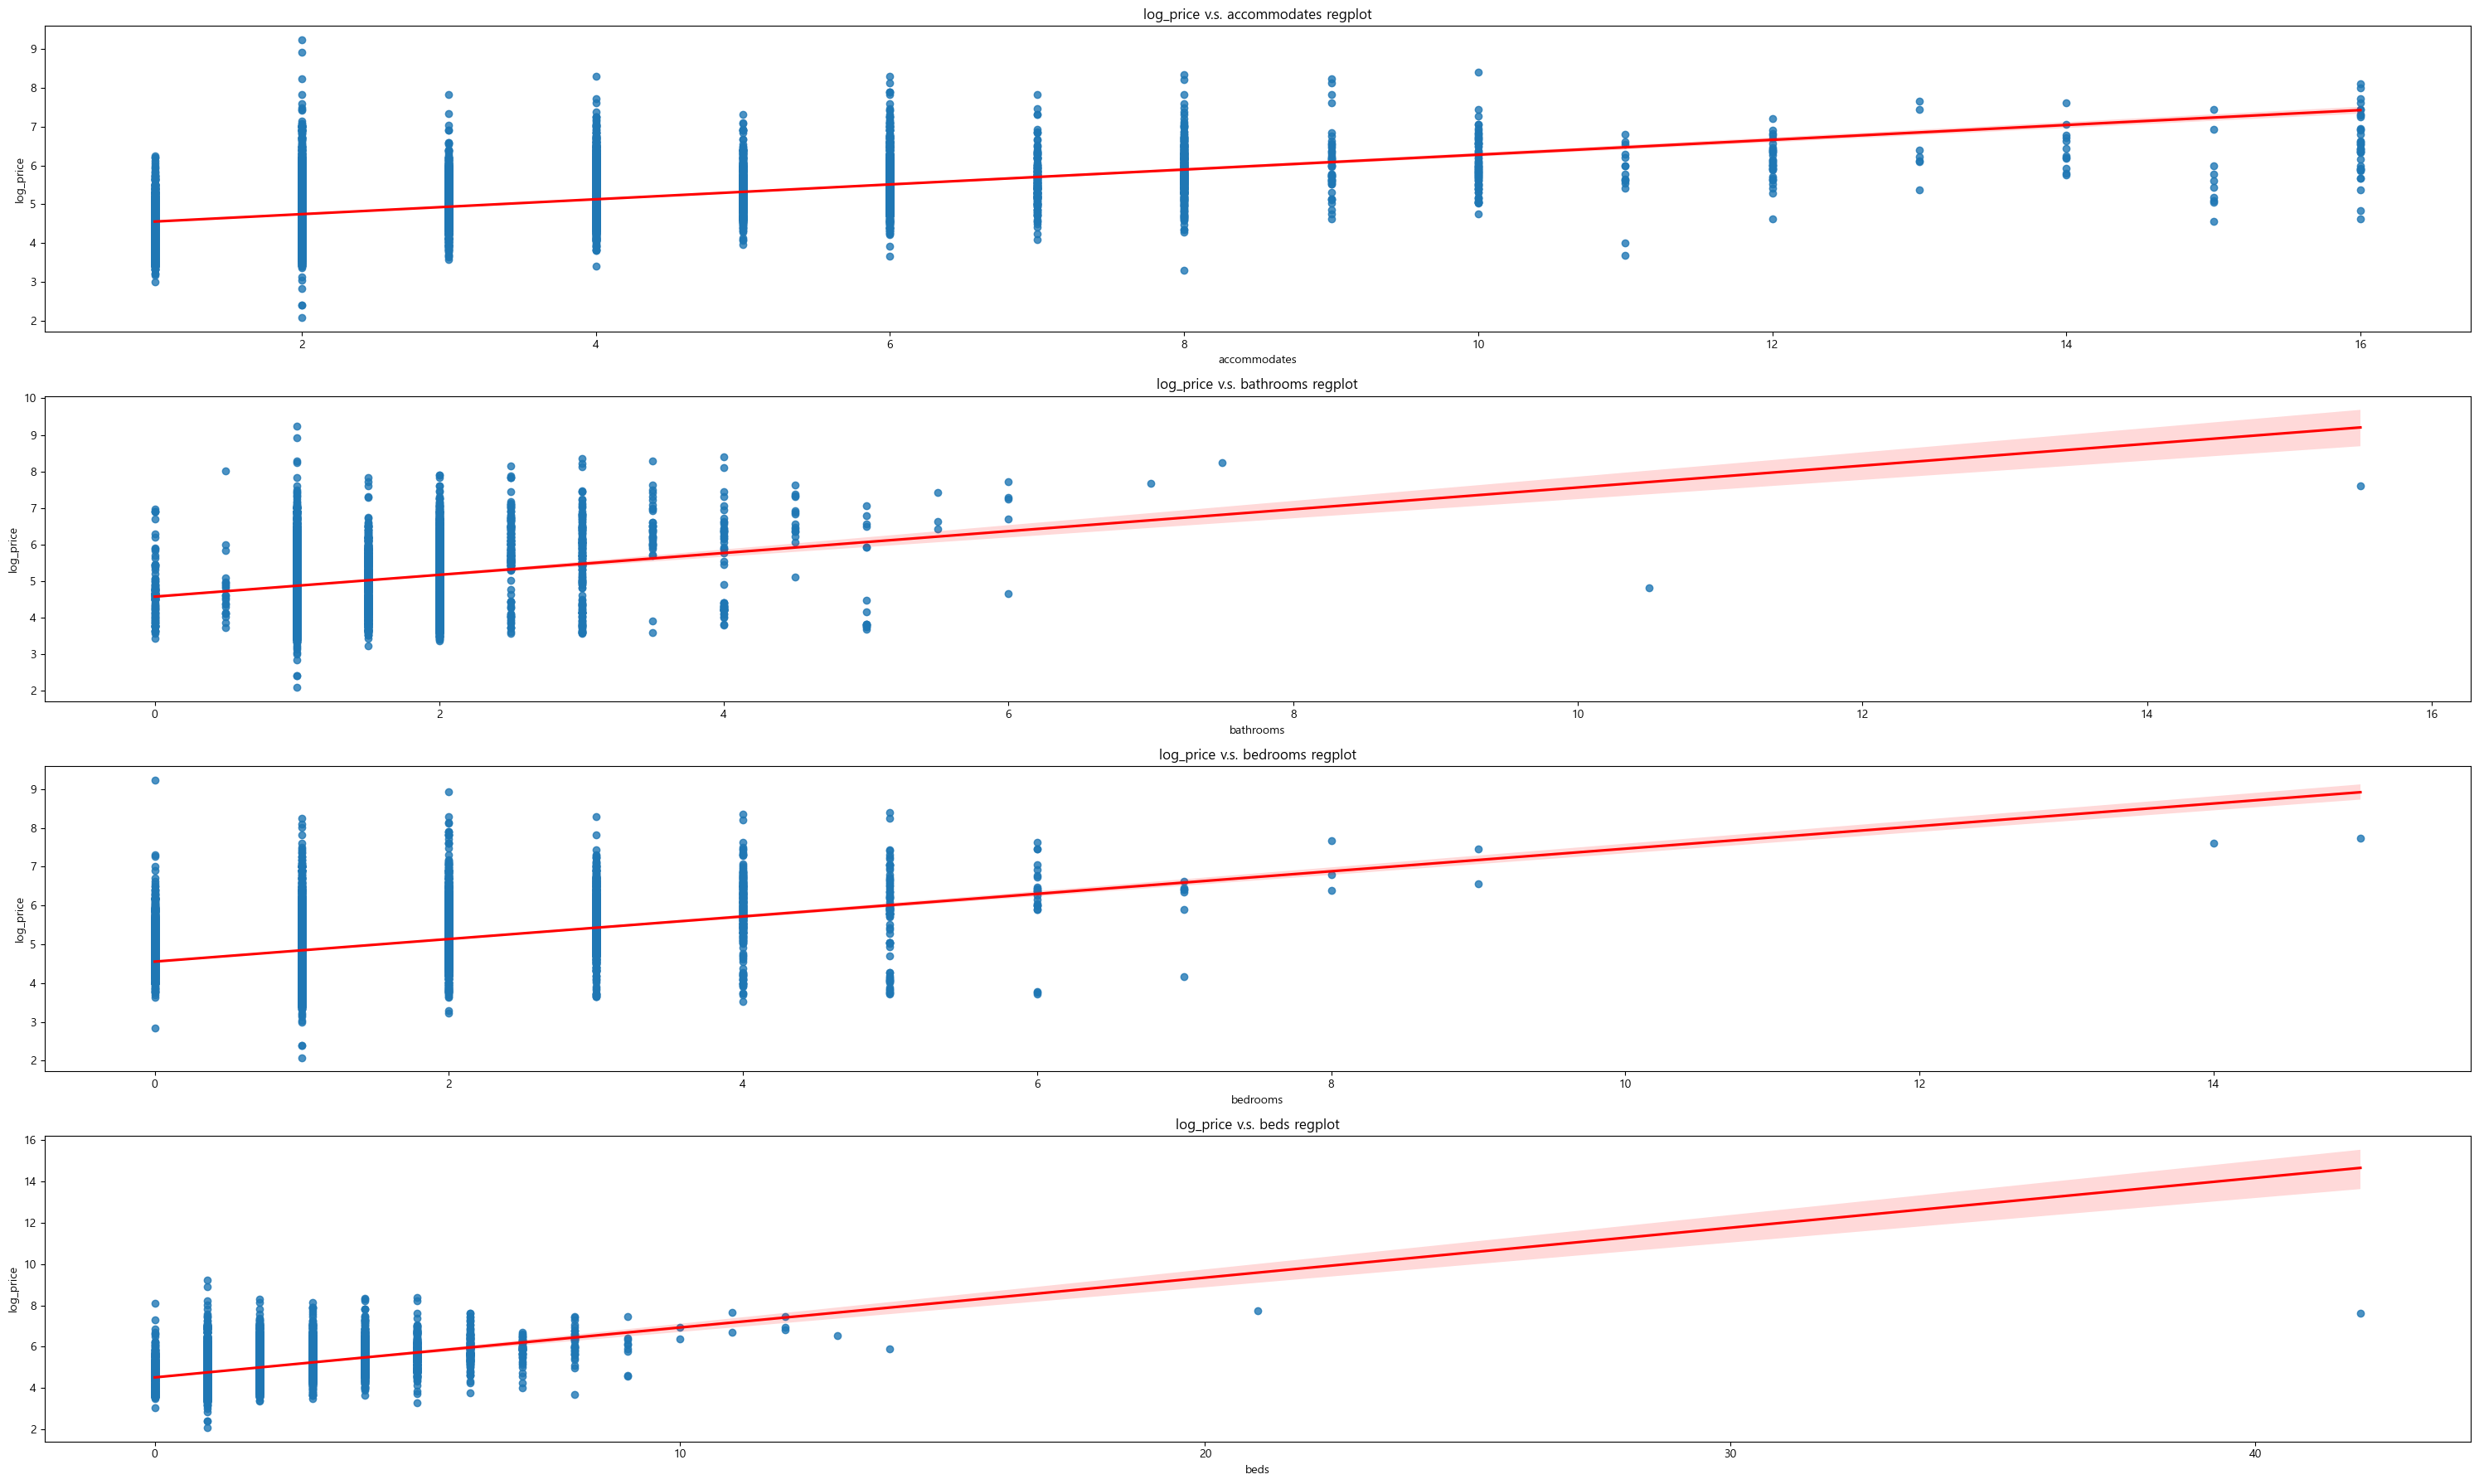

In [23]:
fig, axs = plt.subplots(figsize = (30,18), nrows = 4, ncols = 1)

for i, col in enumerate(['accommodates','bathrooms','bedrooms','beds']):
    sns.regplot(data = df, x = col, y = 'log_price', 
            line_kws = {'color':'red'}, ax = axs[i])
    axs[i].set_title(f'log_price v.s. {col} regplot')

plt.tight_layout()
plt.show()

In [24]:
# 화장실 극단값 데이터 땡기기
display(df['bathrooms'].value_counts().sort_index(ascending=False))
df.loc[df['bathrooms'] > 8, 'bathrooms'] = 7.5
df['bathrooms'].value_counts().sort_index(ascending=False)

bathrooms
15.5        1
10.5        1
7.5         1
7.0         1
6.0         5
5.5         3
5.0        16
4.5        15
4.0        54
3.5        38
3.0       166
2.5       159
2.0      1552
1.5       643
1.0     12016
0.5        22
0.0       107
Name: count, dtype: int64

bathrooms
7.5        3
7.0        1
6.0        5
5.5        3
5.0       16
4.5       15
4.0       54
3.5       38
3.0      166
2.5      159
2.0     1552
1.5      643
1.0    12016
0.5       22
0.0      107
Name: count, dtype: int64

In [25]:
# 침실 극단값 데이터 땡기기
display(df['bedrooms'].value_counts().sort_index(ascending=False))
df.loc[df['bedrooms'] > 10, 'bedrooms'] = 9
df['bedrooms'].value_counts().sort_index(ascending=False)

bedrooms
15.0       1
14.0       1
9.0        2
8.0        3
7.0        7
6.0       24
5.0       85
4.0      241
3.0      946
2.0     2563
1.0     9304
0.0     1602
Name: count, dtype: int64

bedrooms
9.0       4
8.0       3
7.0       7
6.0      24
5.0      85
4.0     241
3.0     946
2.0    2563
1.0    9304
0.0    1602
Name: count, dtype: int64

In [26]:
# 침실 극단값 데이터 땡기기
display(df['bedrooms'].value_counts().sort_index(ascending=False))
df.loc[df['bedrooms'] > 10, 'bedrooms'] = 9
df['bedrooms'].value_counts().sort_index(ascending=False)

bedrooms
9.0       4
8.0       3
7.0       7
6.0      24
5.0      85
4.0     241
3.0     946
2.0    2563
1.0    9304
0.0    1602
Name: count, dtype: int64

bedrooms
9.0       4
8.0       3
7.0       7
6.0      24
5.0      85
4.0     241
3.0     946
2.0    2563
1.0    9304
0.0    1602
Name: count, dtype: int64

In [27]:
# 침대 개수 극단값 데이터 땡기기
display(df['beds'].value_counts().sort_index(ascending=False))
df.loc[df['beds'] > 15, 'beds'] = 14
df['beds'].value_counts().sort_index(ascending=False)

beds
42.0       1
21.0       1
14.0       1
13.0       1
12.0       3
11.0       2
10.0       2
9.0        9
8.0       35
7.0       47
6.0      122
5.0      243
4.0      684
3.0     1374
2.0     3601
1.0     8257
0.0      355
Name: count, dtype: int64

beds
14.0       3
13.0       1
12.0       3
11.0       2
10.0       2
9.0        9
8.0       35
7.0       47
6.0      122
5.0      243
4.0      684
3.0     1374
2.0     3601
1.0     8257
0.0      355
Name: count, dtype: int64

<Axes: >

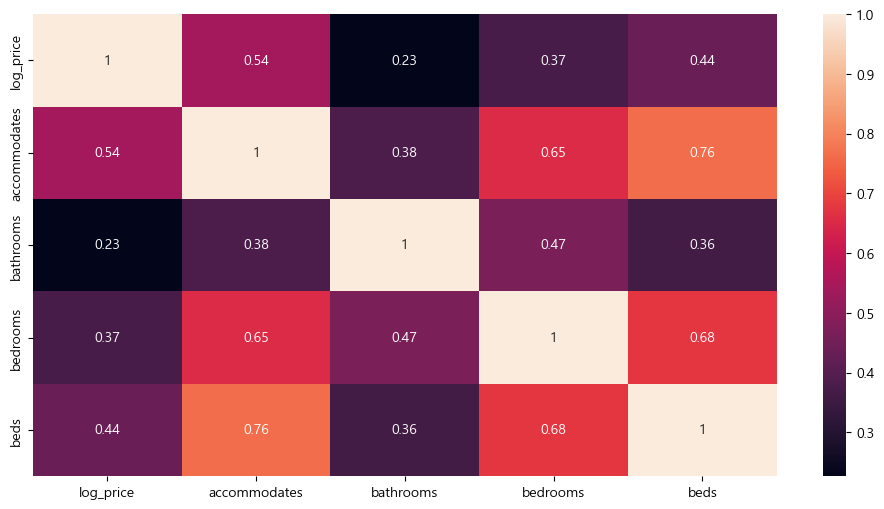

In [28]:
sns.heatmap(df[['log_price','accommodates','bathrooms','bedrooms','beds']].corr(), annot = True)

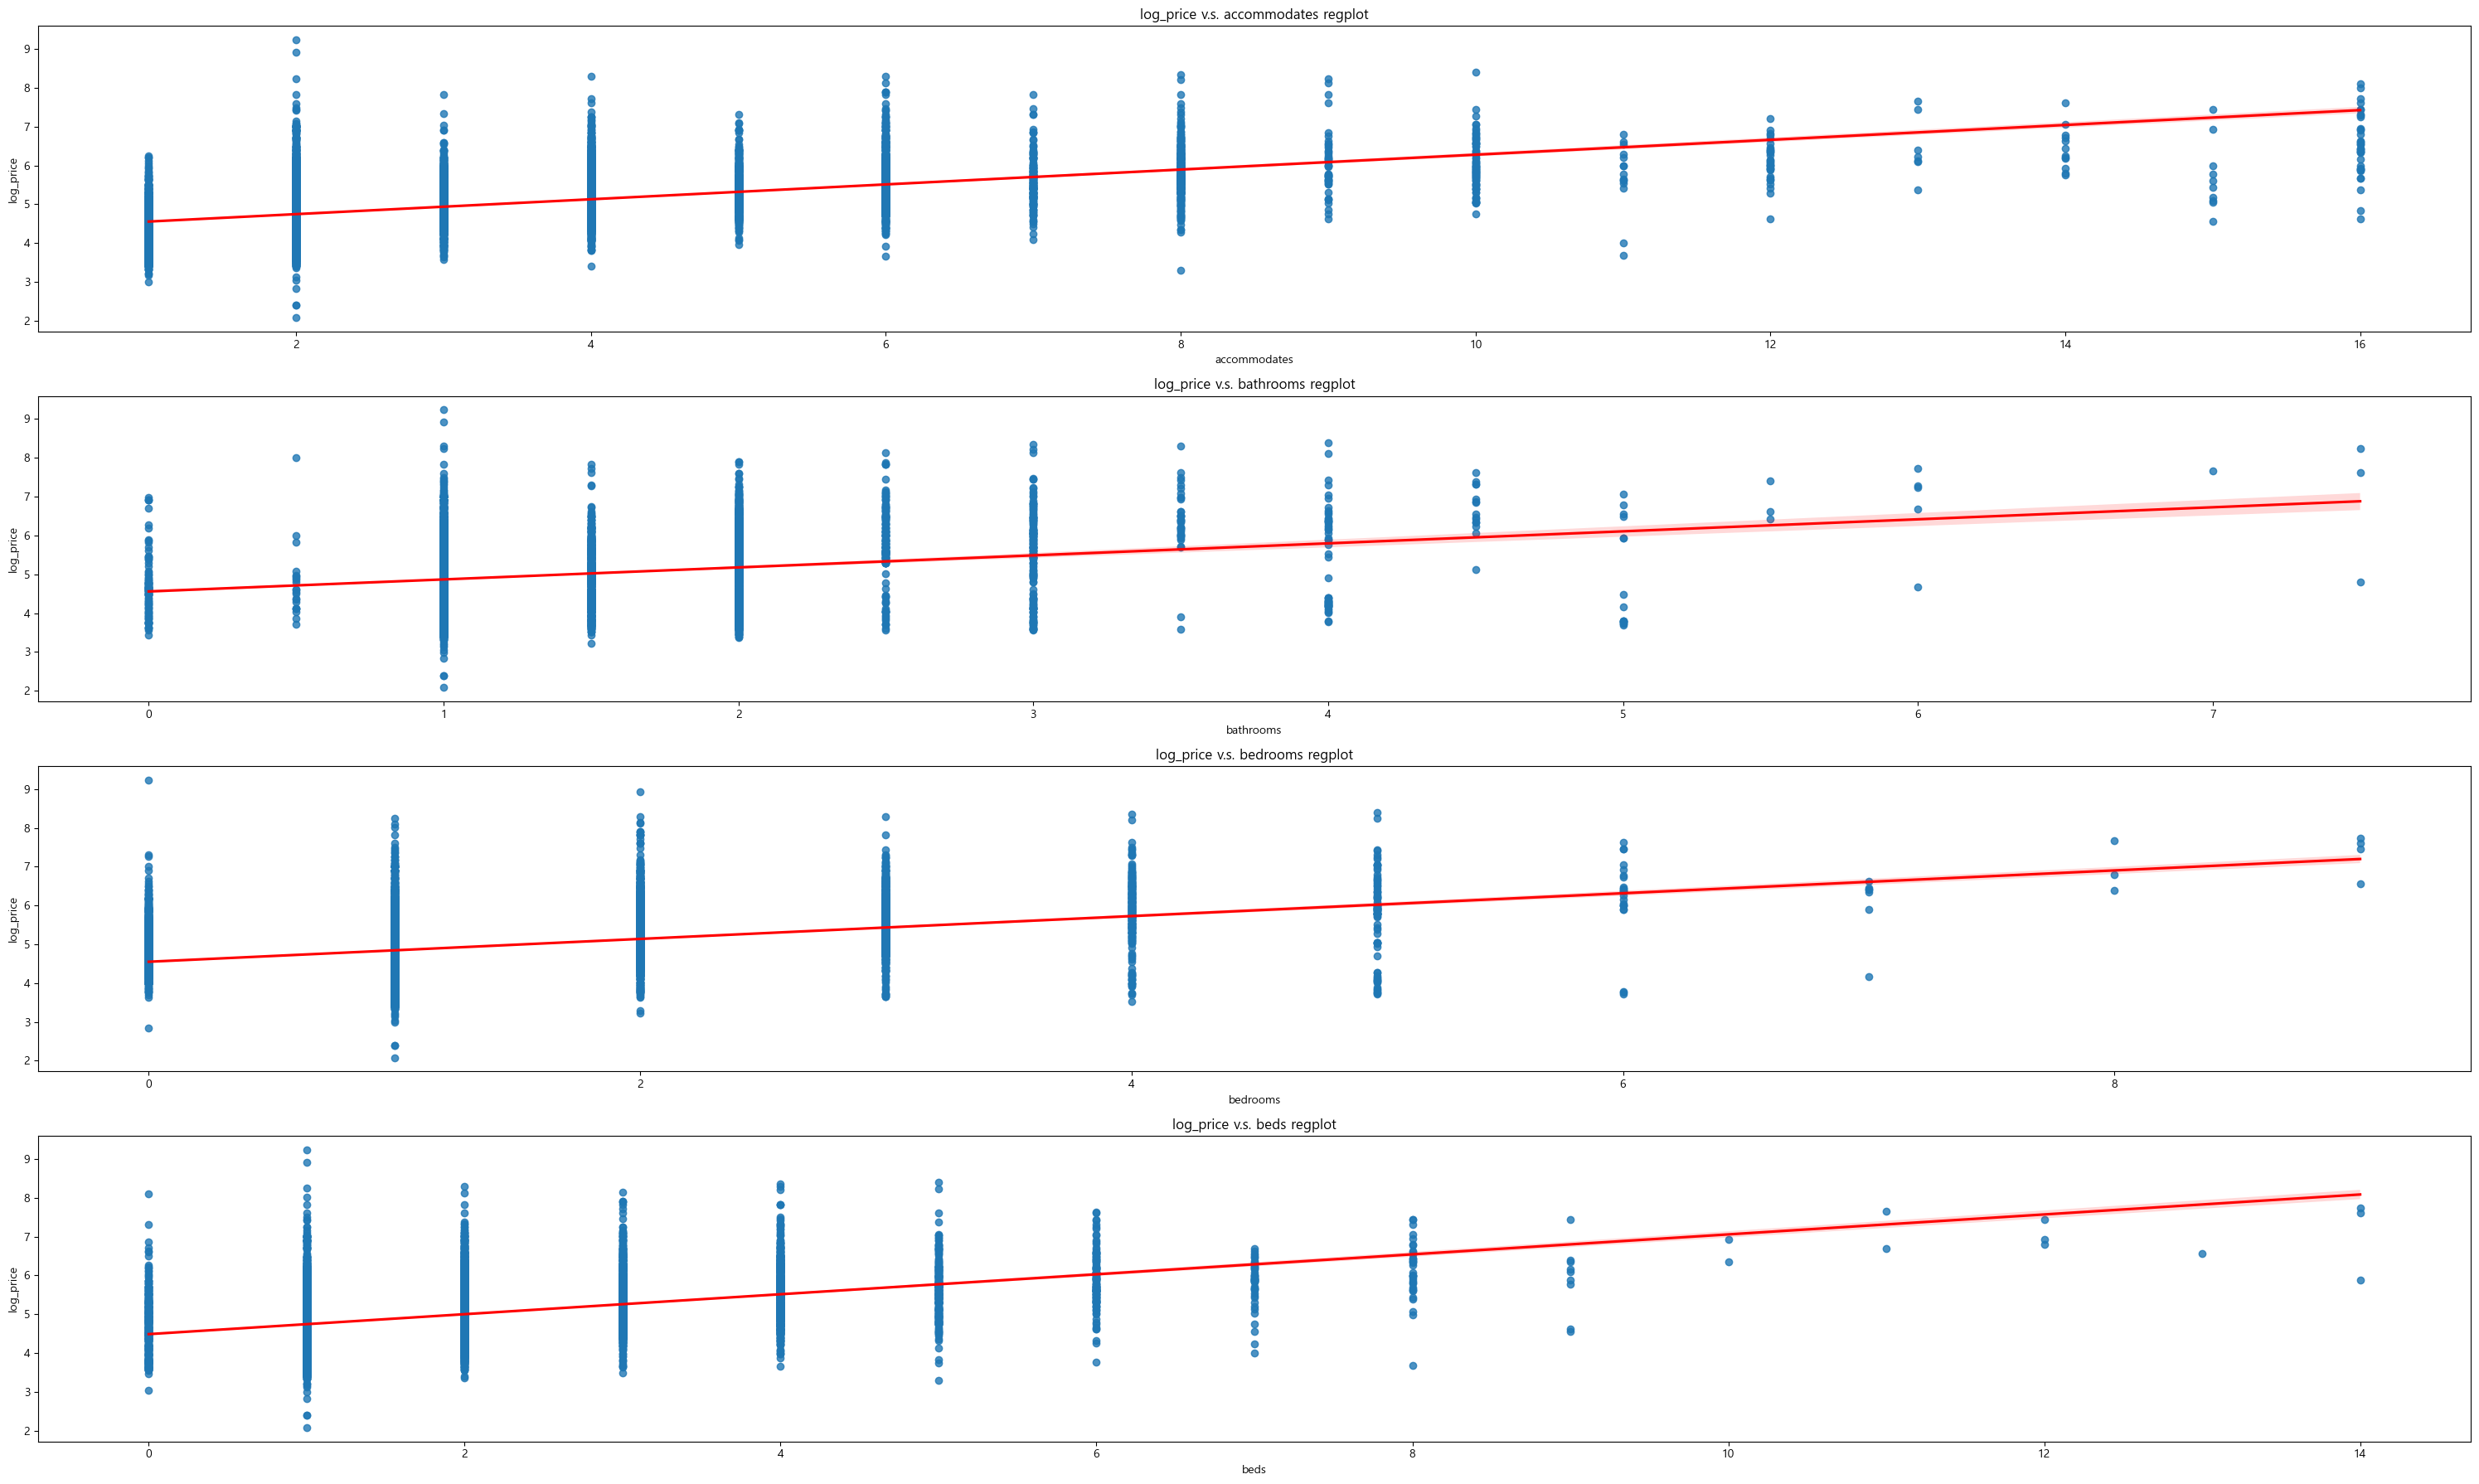

In [29]:
fig, axs = plt.subplots(figsize = (30,18), nrows = 4, ncols = 1)

for i, col in enumerate(['accommodates','bathrooms','bedrooms','beds']):
    sns.regplot(data = df, x = col, y = 'log_price', 
            line_kws = {'color':'red'}, ax = axs[i])
    axs[i].set_title(f'log_price v.s. {col} regplot')

plt.tight_layout()
plt.show()

In [28]:
# 이 코드는 Train/Test 분리 후 적용
q3 = df['log_price'].quantile(0.75) 
q1 = df['log_price'].quantile(0.25)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print(sum(df['log_price'] < lower), sum(df['log_price'] > upper))

7 244


In [29]:
df_temp = df.copy()

df_temp = df_temp.rename(
    columns = {'minimum_minimum_nights':'off_peak_min',
            'maximum_minimum_nights':'peak_min',
            'minimum_maximum_nights':'peak_max',
            'maximum_maximum_nights':'off_peak_max'}
)

df_temp.head()

,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,off_peak_min,peak_min,peak_max,off_peak_max,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,log_price,log_estimated_revenue_l365d,amenities_list,has_self_checkin,has_wifi,has_kitchen,has_dryer,has_air_conditioning,has_heating,has_dedicated_workspace,has_hair_dryer,has_iron,has_gym,has_bbq_grill,has_breakfast,has_fireplace,has_smoking_allowed,has_pets_allowed,has_wine_glasses,has_crib,has_city_skyline_view,has_river_view,has_luggage_dropoff_allowed,has_long_term_stays_allowed,has_private_entrance,has_exterior_security_cameras,has_elevator,has_lock_on_bedroom_door,has_tub,has_washer,has_pool,has_alarm,has_garden_courtyard_view,has_outdoor,has_free_parking,amenities_count,count_appliances_expensive,has_ott,host_experience_months
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,1.0,1,NaN,NaN,NaN,False,Prospect Heights,1.0,3.0,True,True,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200.0,90,365,90.0,90.0,365.0,365.0,90.0,365.0,True,27,57,87,362,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,False,1,0,1,0,0.05,1,1,1,5.303305,0.000000,"['refrigerator', 'dishes and silverware', 'wif...",0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,7,1,0,183.0
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,1.0,0,NaN,NaN,1.00,False,East Harlem,1.0,1.0,True,True,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82.0,30,999,30.0,30.0,999.0,999.0,30.0,999.0,True,0,0,0,204,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,False,1,0,1,0,0.58,1,1,0,4.418841,0.000000,"['oven', 'blender', 'luggage dropoff allowed',...",0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,32,5,0,176.0
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,1.0,1,within a few hours,1.0,0.40,False,Boerum Hill,1.0,3.0,True,True,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765.0,3,60,3.0,3.0,60.0,60.0,3.0,60.0,True,30,49,66,326,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,False,1,0,1,0,0

In [41]:
df['host_response_time']

0                       NaN
1                       NaN
2        within a few hours
3            within an hour
4            within an hour
                ...        
22235        within an hour
22239        within an hour
22240    within a few hours
22287                   NaN
22288                   NaN
Name: host_response_time, Length: 14804, dtype: str

In [ ]:
df['calculated_host_listings_count']

In [107]:
df.loc[df['minimum_nights_avg_ntm'] < 30, 'license'].isna().sum()

np.int64(17)

maximum_minimum_nigths : 예약을 하기 어려울 때 최소 숙박일수(성수기)

minimum_minimum_nigths : 예약을 하기 쉬울 때 최소 숙박일수(비수기)

In [154]:
df_temp = df.copy()

df_temp = df_temp.rename(
    columns = {'minimum_minimum_nights':'off_peak_min',
            'maximum_minimum_nights':'peak_min',
            'minimum_maximum_nights':'peak_max',
            'maximum_maximum_nights':'off_peak_max'}
)

len(df_temp.loc[df_temp['off_peak_min'] != df_temp['peak_min'],:])

2847

In [ ]:
import pydeck as pdk

#### property_type으로 묶어가면서 보쉴?
# df['property_type'] = 무언가로 대충 묶어서

plot_df = df[['latitude','longitude','property_type','price']].dropna().copy()
plot_df = plot_df.reset_index(drop = True)

unique_cats = plot_df['property_type'].unique()

cmap = plt.get_cmap('Set1')

auto_color_lookup = {
    cat: [int(x * 255) for x in cmap(i)[:3]] + [160]
    for i, cat in enumerate(unique_cats)
}

plot_df['type_color'] = plot_df['property_type'].map(auto_color_lookup)

# 지도 중심점 표시
view_state = pdk.ViewState(
    latitude = plot_df['latitude'].mean(),
    longitude = plot_df['longitude'].mean(),
    zoom = 10,
    pitch = 30
)

layer = pdk.Layer(
    'ColumnLayer',
    plot_df.to_dict('records'),
    get_position = ['longitude','latitude'],
    get_fill_color = 'type_color',
    radius = 40,
    get_elevation = 'price', # 높이는 price
    elevation_scale = 1,
    pickable = True,
    stroked = True,
    filled = True,
    extruded = True,
    auto_highlight = True,
)


r = pdk.Deck(layers=[layer], initial_view_state=view_state)
r.to_html("docs/images/property_type_with_price.html", notebook_display=False)

In [124]:
import pydeck as pdk

#### property_type으로 묶어가면서 보쉴?
# df['property_type'] = 무언가로 대충 묶어서

plot_df = df[['latitude','longitude','room_type','price']].dropna().copy()
plot_df = plot_df.reset_index(drop = True)

unique_cats = plot_df['room_type'].unique()

cmap = plt.get_cmap('Set1')

auto_color_lookup = {
    cat: [int(x * 255) for x in cmap(i)[:3]] + [160]
    for i, cat in enumerate(unique_cats)
}

plot_df['type_color'] = plot_df['room_type'].map(auto_color_lookup)

# 지도 중심점 표시
view_state = pdk.ViewState(
    latitude = plot_df['latitude'].mean(),
    longitude = plot_df['longitude'].mean(),
    zoom = 10,
    pitch = 30
)

layer = pdk.Layer(
    'ColumnLayer',
    plot_df.to_dict('records'),
    get_position = ['longitude','latitude'],
    get_fill_color = 'type_color',
    radius = 40,
    get_elevation = 'price', # 높이는 price
    elevation_scale = 1,
    pickable = True,
    stroked = True,
    filled = True,
    extruded = True,
    auto_highlight = True,
)


r = pdk.Deck(layers=[layer], initial_view_state=view_state)
r.to_html("docs/images/room_type_with_price.html", notebook_display=False)